In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, get_color, get_color_and_match, get_msmhmr

from multicam_tng.multicam2 import multicam_prediction

from multicam_tng.utils import TNG_H

In [2]:
# stellar mass of 100 particles (should be the lowest mass we consider)
np.log10(1.4e6 * 100 * TNG_H)

np.float64(7.97697322798685)

In [3]:
# read tree data 
hydro_data = {} 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    out = np.load(fp)
    for k in out: 
        hydro_data[k] = out[k]


In [4]:
# how complete? 
# compute number of galaxies in stellar bin that are not in mpeak bin
cond1 = (hydro_data['stellar_mass'] > 10**9.5 ) & (hydro_data['stellar_mass'] < 10**10.2 )
cond2 = (hydro_data['mpeak'] < 10**11 ) | (hydro_data['mpeak'] > 10**12 )
sum(cond1 & cond2) / sum(cond1) # ~ 1% is OK

np.float64(0.013070283600493218)

In [5]:
hydro_data.keys()

dict_keys(['subfind_id', 'vpeak', 'mpeak_mah', 'is_sub', 'a12', 'mpeak_pre', 'mpeak', 'stellar_mass'])

In [6]:
# sort array by subfind ids to match with color data
_sort_mask = np.argsort(hydro_data['subfind_id'])
for k in hydro_data:
    hydro_data[k] = hydro_data[k][_sort_mask]

In [7]:
hydro_data['subfind_id'], hydro_data['stellar_mass'], hydro_data['mpeak']

(array([      0,       1,       2, ..., 3577883, 3741554, 4263941],
       shape=(101431,)),
 array([1.6383422e+12, 2.5731015e+11, 2.8852679e+11, ..., 1.9287528e+06,
        0.0000000e+00, 0.0000000e+00], shape=(101431,), dtype=float32),
 array([2.7477936e+14, 3.7301757e+13, 4.1831337e+13, ..., 1.8157779e+10,
        1.0704213e+10, 1.3181168e+10], shape=(101431,), dtype=float32))

In [8]:
# define stellar mass bin to be used throughout

stellar_mass_bin = (9.5, 10.2 ) # log10 Msun / h units 
cond1 = hydro_data['stellar_mass'] > 10**stellar_mass_bin[0]
cond2 = hydro_data['stellar_mass'] < 10**stellar_mass_bin[1]
stellar_mask = cond1 & cond2
sum(stellar_mask)

np.int64(4055)

In [9]:
# see notebook "2025-11-10 Mass bin MultiCAM Trying Mpeak"
mpeak_mass_bin = (11, 12) # log10 Msun / h units 

mpeak = np.log10(hydro_data['mpeak']) # min = 1e10
left_cond = mpeak > mpeak_mass_bin[0]
right_cond = mpeak < mpeak_mass_bin[1]
# star_cond =hydro_data['stellar_mass'] > 0
star_cond = hydro_data['stellar_mass'] > np.log10(1.4e6 * 100 * TNG_H)
mpeak_mask = left_cond & right_cond & star_cond
sum(mpeak_mask)

np.int64(11316)

In [10]:
# get colors
color_file = "../../data/Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc_099.hdf5"
colors = get_color_and_match(color_file, hydro_data['subfind_id'])
gi_color = colors['sdss_g'].values - colors['sdss_i'].values
gi_color.shape

(101431,)

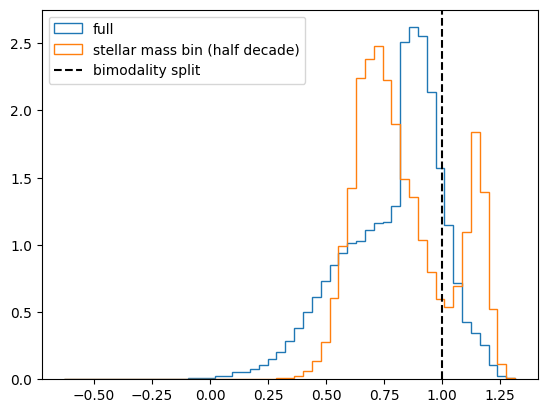

In [11]:
_, bins, _ = plt.hist(gi_color, bins=51, density=True, histtype='step', label='full');

# just as an example to see bimodality
plt.hist(gi_color[stellar_mask], bins=bins, density=True, 
         histtype='step', label='stellar mass bin (half decade)');

plt.axvline(1.0, c='k', ls='--', label='bimodality split')
plt.legend()


Text(0, 0.5, 'log10 Stellar Mass')

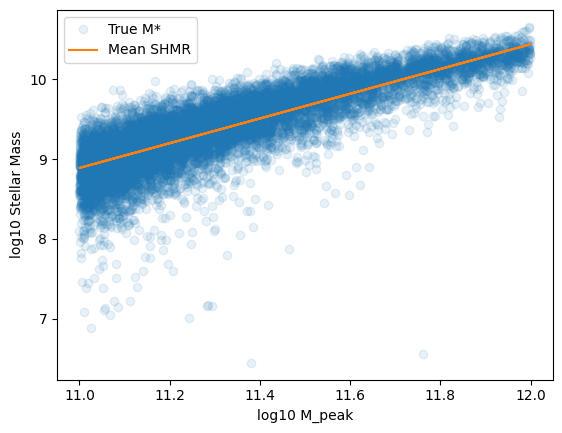

In [12]:
# get deviation from mean SHMR and check that it looks correct
_smass = np.log10(hydro_data['stellar_mass'][mpeak_mask])
_mpeak =  mpeak[mpeak_mask] # already log10

mstar_dev, (m, b) = get_msmhmr(_smass,_mpeak, n_bins=11, mass_bin=mpeak_mass_bin)

_y_pred = np.log10(10 ** (m * _mpeak + b) * 10**_mpeak)
plt.plot(_mpeak, _smass, 'o', alpha=0.1, label='True M*')
plt.plot(_mpeak, _y_pred, '-', label="Mean SHMR")
plt.legend()

plt.xlabel("log10 M_peak")
plt.ylabel("log10 Stellar Mass") 



In [13]:
# get snapshot redshifts and scales
import pandas as pd
metadata = pd.read_csv("../../data/tng300-1-table.csv") # this ist just metadata which sims share
redshift =metadata['Redshift'].values
scales = 1 / (1 + redshift)

# Preliminary Look at Correlations

In [14]:
# correlation deviation and a12 
from scipy.stats import spearmanr
spearmanr(mstar_dev, hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6496573288768798), pvalue=np.float64(0.0))

In [15]:
spearmanr(gi_color[mpeak_mask], hydro_data['a12'][mpeak_mask])

SignificanceResult(statistic=np.float64(-0.6239754787528624), pvalue=np.float64(0.0))

In [16]:
# correlation across MAH (deviation and color)
mah = hydro_data['mpeak_mah'][mpeak_mask]
color = gi_color[mpeak_mask]
n_snaps = mah.shape[1]

corrs_mstar_dev = [] 
corrs_color = [] 
for ii in range(n_snaps):
    corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
    corrs_color.append(spearmanr(color, mah[:, ii]).statistic)

corrs_mstar_dev = np.array(corrs_mstar_dev)
corrs_color = np.array(corrs_color)
    

/tmp/ipykernel_21218/1328140465.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_mstar_dev.append(spearmanr(mstar_dev, mah[:, ii]).statistic)
/tmp/ipykernel_21218/1328140465.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corrs_color.append(spearmanr(color, mah[:, ii]).statistic)


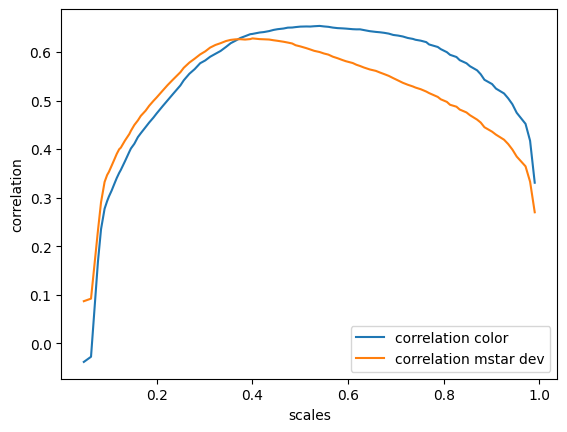

In [17]:
plt.plot(scales, corrs_color, label='correlation color')
plt.plot(scales, corrs_mstar_dev, label='correlation mstar dev')
plt.xlabel('scales')
plt.ylabel('correlation')
plt.legend()

# Train and Apply MultiCAM (Linear)

In [18]:
# np.unique(hydro_data['a12'][mpeak_mask]), sum(mpeak_mask)

In [19]:
# x = mah
x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 1), (11316, 1))

In [21]:
y_pred = multicam_prediction(x, x, y)
y_pred.shape

(11316, 1)

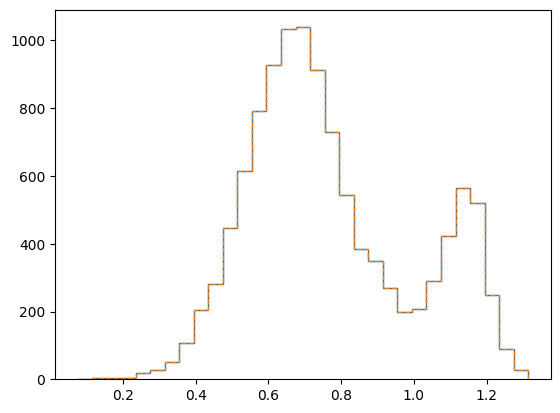

In [22]:
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');

In [23]:
spearmanr(y_pred[:, 0], y[:, 0])

SignificanceResult(statistic=np.float64(0.6319214606818059), pvalue=np.float64(0.0))

## MAH 

In [24]:
x = mah
# x = hydro_data['a12'][mpeak_mask].reshape(-1, 1)
y = np.stack([gi_color[mpeak_mask]], axis=-1)
x.shape, y.shape

((11316, 100), (11316, 1))

In [25]:
y_pred = multicam_prediction(x, x, y)
y_pred.shape

(11316, 1)

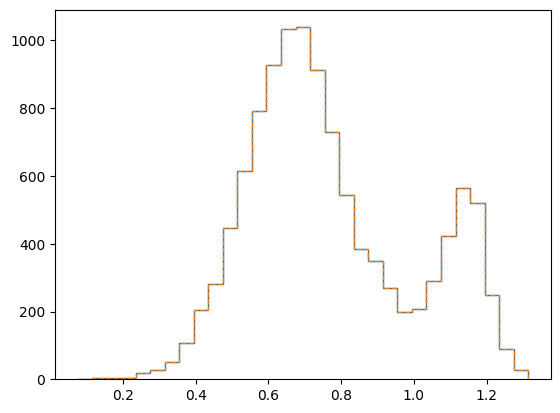

In [26]:
_, bins, _ = plt.hist(y[:, 0], bins=31, histtype='step')
plt.hist(y_pred[:, 0], bins=bins, histtype='step', ls='--');

In [27]:
spearmanr(y_pred[:, 0], y[:, 0])

SignificanceResult(statistic=np.float64(0.7519813235410026), pvalue=np.float64(0.0))